In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
from scipy.stats import levy_stable, kstest, norm
from src.simulators import *
from src.estimators import *

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE = sns.color_palette("tab10")
sns.set_style("darkgrid")

# Lévy Flight Fitting to GPS Tracking Data
---

**Dataset:** White Storks (*Ciconia ciconia*)

### Approach
We fit an **α-stable distribution** S(α, β, σ, μ) directly to **step lengths** (distances between consecutive GPS fixes), consistent with the ecological Lévy flight literature.

Step lengths are always positive, so we expect the estimators to converge toward **β ≈ 1** (maximally right-skewed, one-sided distribution).

## 1. Data Loading

In [2]:
DATA_PATH = "data/whitestork/clean_df_whitestork_steps.csv"
df_whitestorks = pd.read_csv(DATA_PATH)
print(f"\nClean dataset : {len(df_whitestorks):,} rows, {df_whitestorks['individual_id'].nunique()} individuals")



Clean dataset : 1,492,640 rows, 72 individuals


## 2. Exploratory Analysis

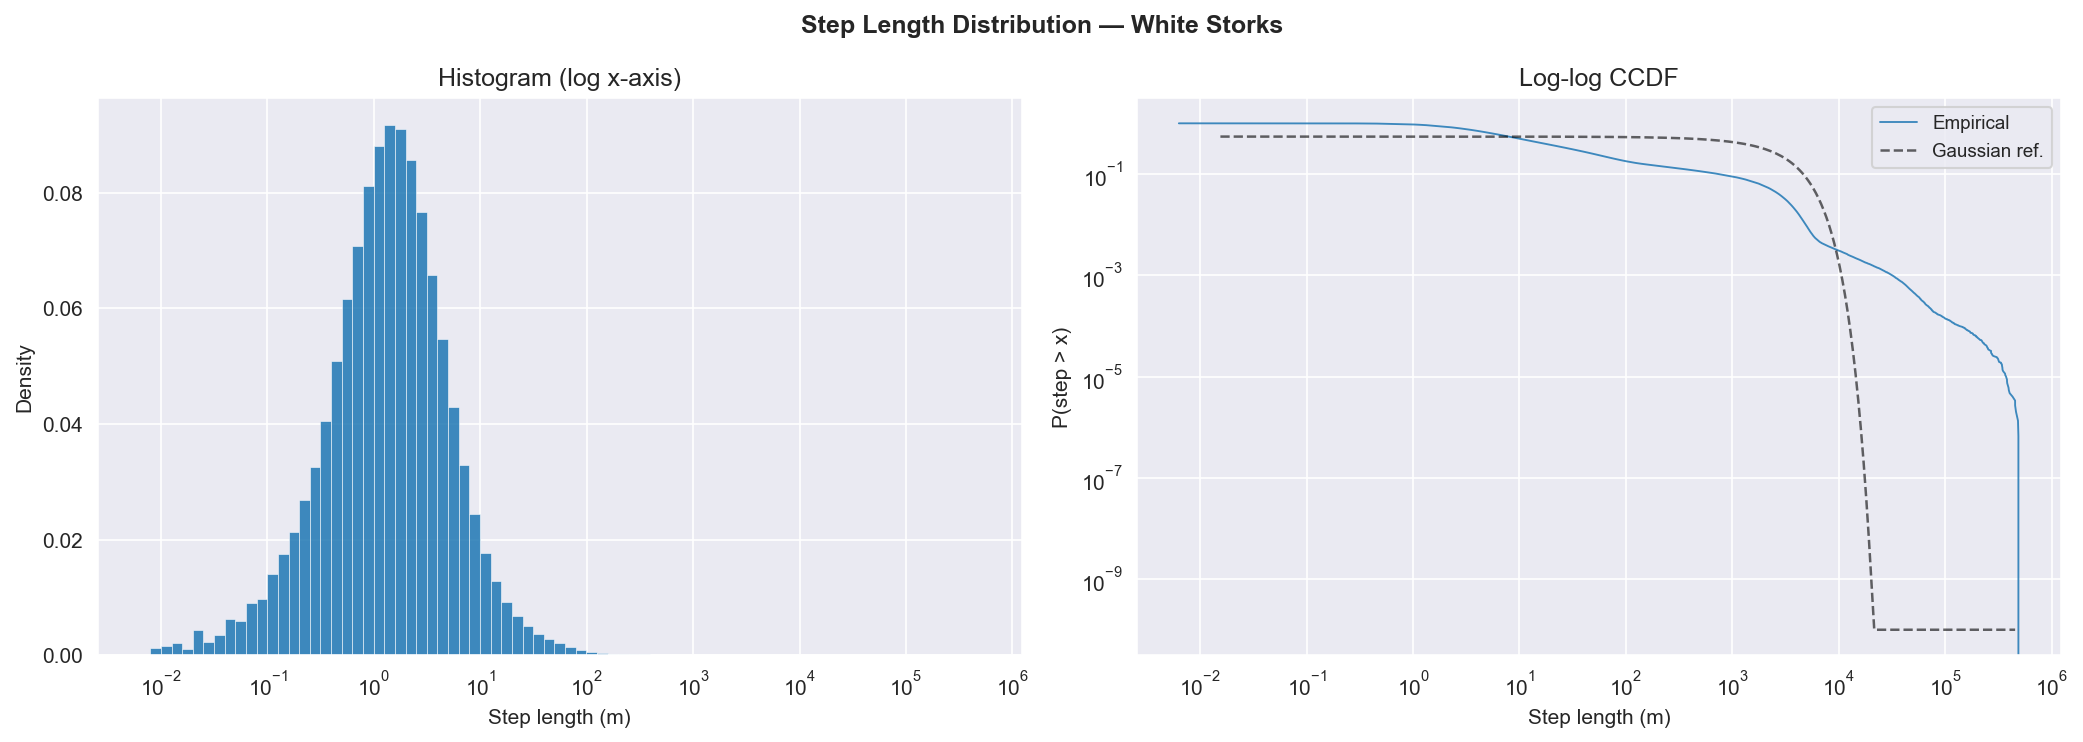

In [3]:
step_vals = df_whitestorks["step_m"].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Step Length Distribution — White Storks", fontweight="bold")

# Histogram with log-spaced bins
ax = axes[0]
bins = np.logspace(np.log10(step_vals.min()), np.log10(step_vals.max()), 80)
ax.hist(step_vals, bins=bins, density=True,
        color=PALETTE[0], edgecolor="white", linewidth=0.3, alpha=0.85)
ax.set_xscale("log")
ax.set_xlabel("Step length (m)")
ax.set_ylabel("Density")
ax.set_title("Histogram (log x-axis)")

# Log-log CCDF
ax = axes[1]
sorted_s = np.sort(step_vals)
ccdf = 1 - np.arange(1, len(sorted_s) + 1) / len(sorted_s)
ax.loglog(sorted_s, ccdf, linewidth=0.9, color=PALETTE[0], alpha=0.85, label="Empirical")

# Gaussian reference: P(X > x) for X ~ N(mu, sigma), x > 0
x_ref = np.logspace(np.log10(sorted_s[20]), np.log10(sorted_s[-5]), 300)
gauss_ccdf = 1 - norm.cdf(x_ref, step_vals.mean(), step_vals.std())
gauss_ccdf = np.clip(gauss_ccdf, 1e-10, 1)
ax.loglog(x_ref, gauss_ccdf, "k--", linewidth=1.2, alpha=0.6, label="Gaussian ref.")

ax.set_xlabel("Step length (m)")
ax.set_ylabel("P(step > x)")
ax.set_title("Log-log CCDF")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 3. α-Stable Parameter Estimation

All three estimators can be applied to the pooled `step_m` values.
Because step lengths are positive, we expect **β ≈ 1** in all fits.

| Estimator | Method | Speed |
|:---|:---|:---|
| McCulloch | quantile look-up tables | fast |
| Koutrouvelis | characteristic-function regression | medium |
| scipy MLE | maximum likelihood | slow (and skipped in this notebook) |

In [4]:
ESTIMATORS = {
    "McCulloch":    mcculloch_estimator,
    "Koutrouvelis": koutrouvelis_estimator,
    #"scipy MLE":    scipy_mle, #skip this one because it takes very long and after fixing Koutrouvelis it's comparable with MLE
}

results = {}

print(f"{'Estimator':<15} {'alpha':>7} {'beta':>7} {'sigma(m)':>10} {'mu(m)':>10}")
print("-" * 55)

for name, est in ESTIMATORS.items():
    a, b, s, m = est(step_vals)
    results[name] = {"alpha": a, "beta": b, "sigma": s, "mu": m}
    print(f"{name:<15} {a:>7.4f} {b:>7.4f} {s:>10.2f} {m:>10.2f}")

Estimator         alpha    beta   sigma(m)      mu(m)
-------------------------------------------------------
McCulloch        0.5008  1.0000      22.92       9.85
Koutrouvelis     0.5313  0.9749       4.55      -0.41


In [5]:
df_res = pd.DataFrame(results, index=["alpha", "beta", "sigma", "mu"]).T.round(4)
display(df_res)

,alpha,beta,sigma,mu
McCulloch,0.5008,1.0000,22.916,9.8505
Koutrouvelis,0.5313,0.9749,4.545,-0.4139


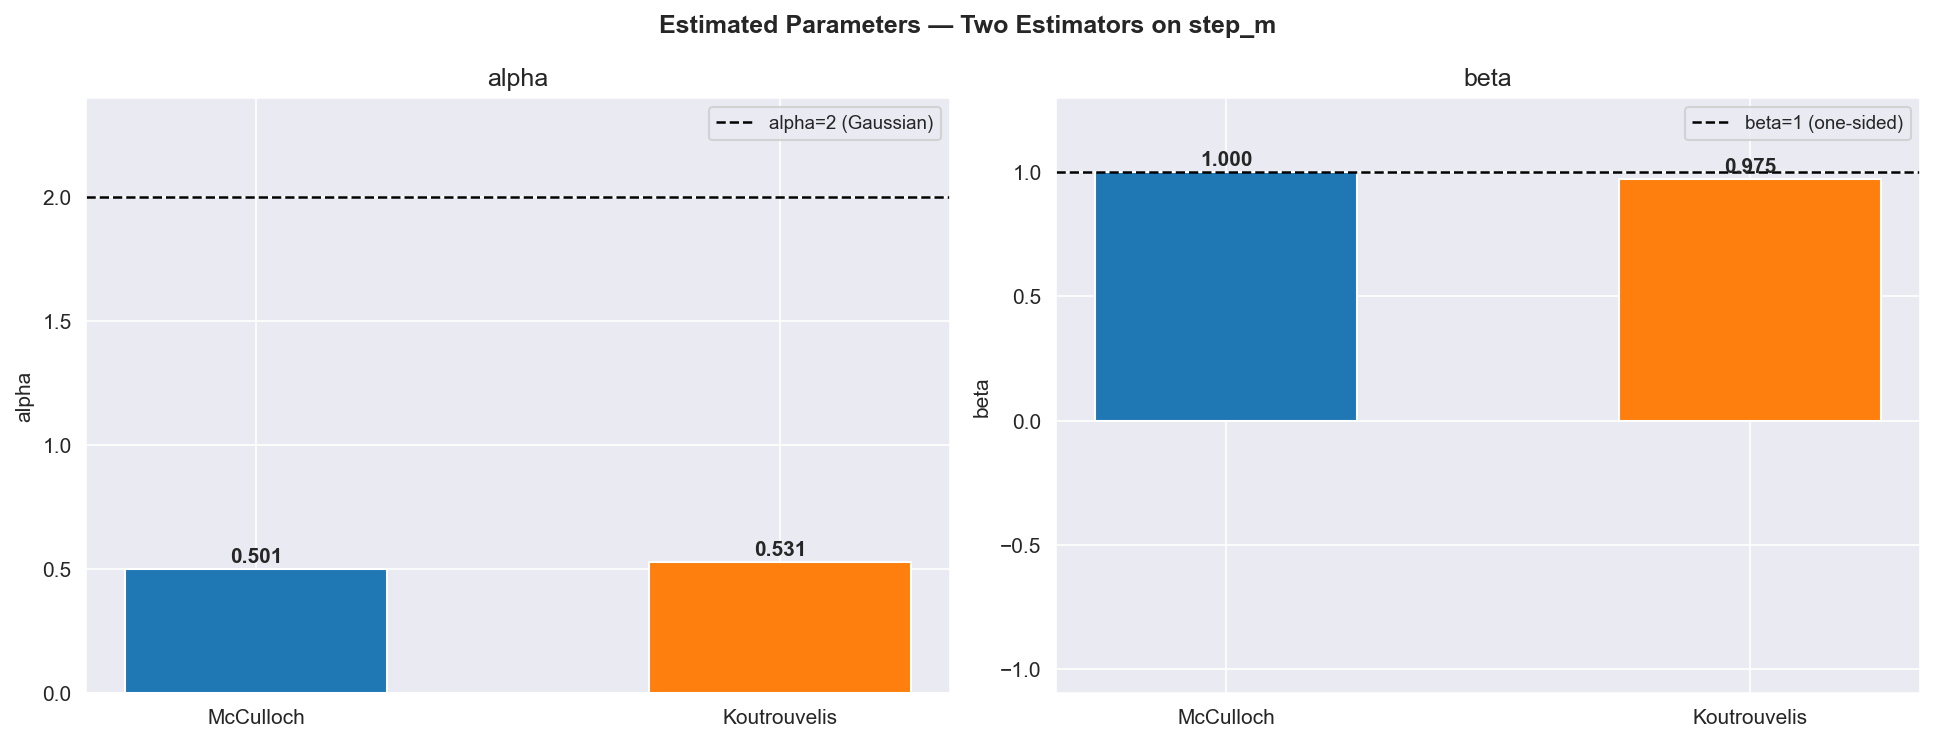

In [6]:
est_names = list(ESTIMATORS.keys())
x = np.arange(len(est_names))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Estimated Parameters — Two Estimators on step_m", fontweight="bold")

for ax, param, ylabel in zip(axes, ["alpha", "beta"], ["alpha", "beta"]):
    vals = [results[n][param] for n in est_names]
    bars = ax.bar(x, vals, color=PALETTE[:3], width=0.5, edgecolor="white")
    if param == "alpha":
        ax.axhline(2.0, color="black", linestyle="--", linewidth=1.2, label="alpha=2 (Gaussian)")
        ax.set_ylim(0, 2.4)
    else:
        ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2, label="beta=1 (one-sided)")
        ax.set_ylim(-1.1, 1.3)
    ax.set_xticks(x)
    ax.set_xticklabels(est_names, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2, val + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold",
        )

plt.tight_layout()
plt.show()

C:\Users\User1\AppData\Local\Temp\ipykernel_16636\3688119912.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)
C:\Users\User1\AppData\Local\Temp\ipykernel_16636\3688119912.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


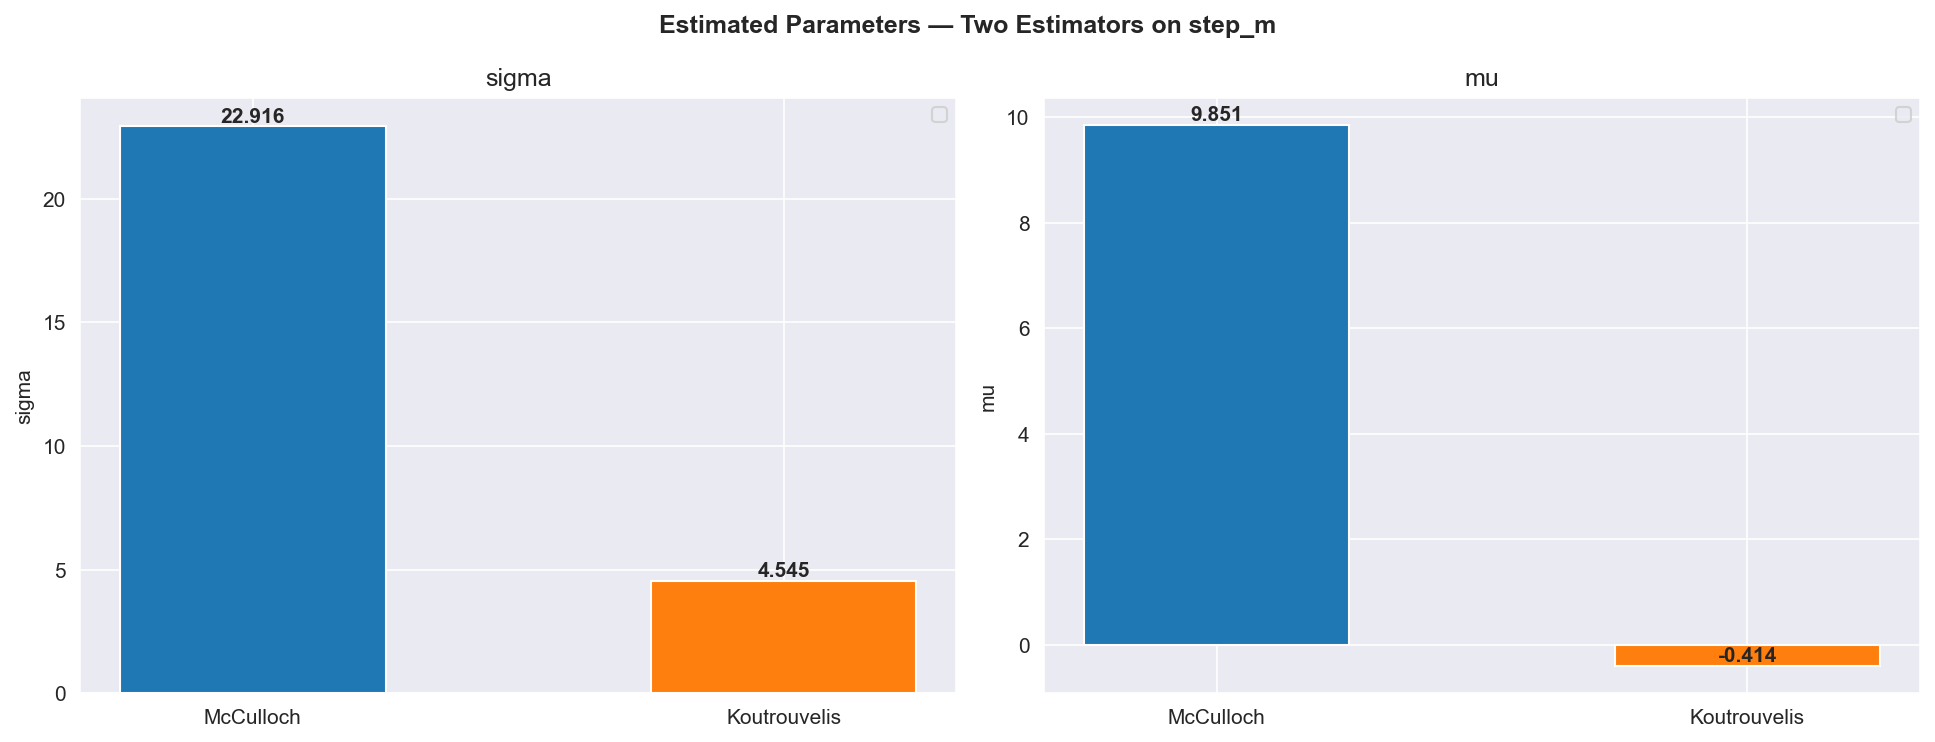

In [16]:
est_names = list(ESTIMATORS.keys())
x = np.arange(len(est_names))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Estimated Parameters — Two Estimators on step_m", fontweight="bold")

for ax, param, ylabel in zip(axes, ["sigma", "mu"], ["sigma", "mu"]):
    vals = [results[n][param] for n in est_names]
    bars = ax.bar(x, vals, color=PALETTE[:3], width=0.5, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(est_names, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2, val + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold",
        )

plt.tight_layout()
plt.show()

## 4. Goodness of Fit

Using **scipy MLE** parameters (most accurate):
1. **QQ-plot** — theoretical vs empirical quantiles of step_m
2. **Density overlay** — fitted PDF vs histogram on log x-axis
3. **KS test** — max CDF deviation (subsampled to 2 000 pts)

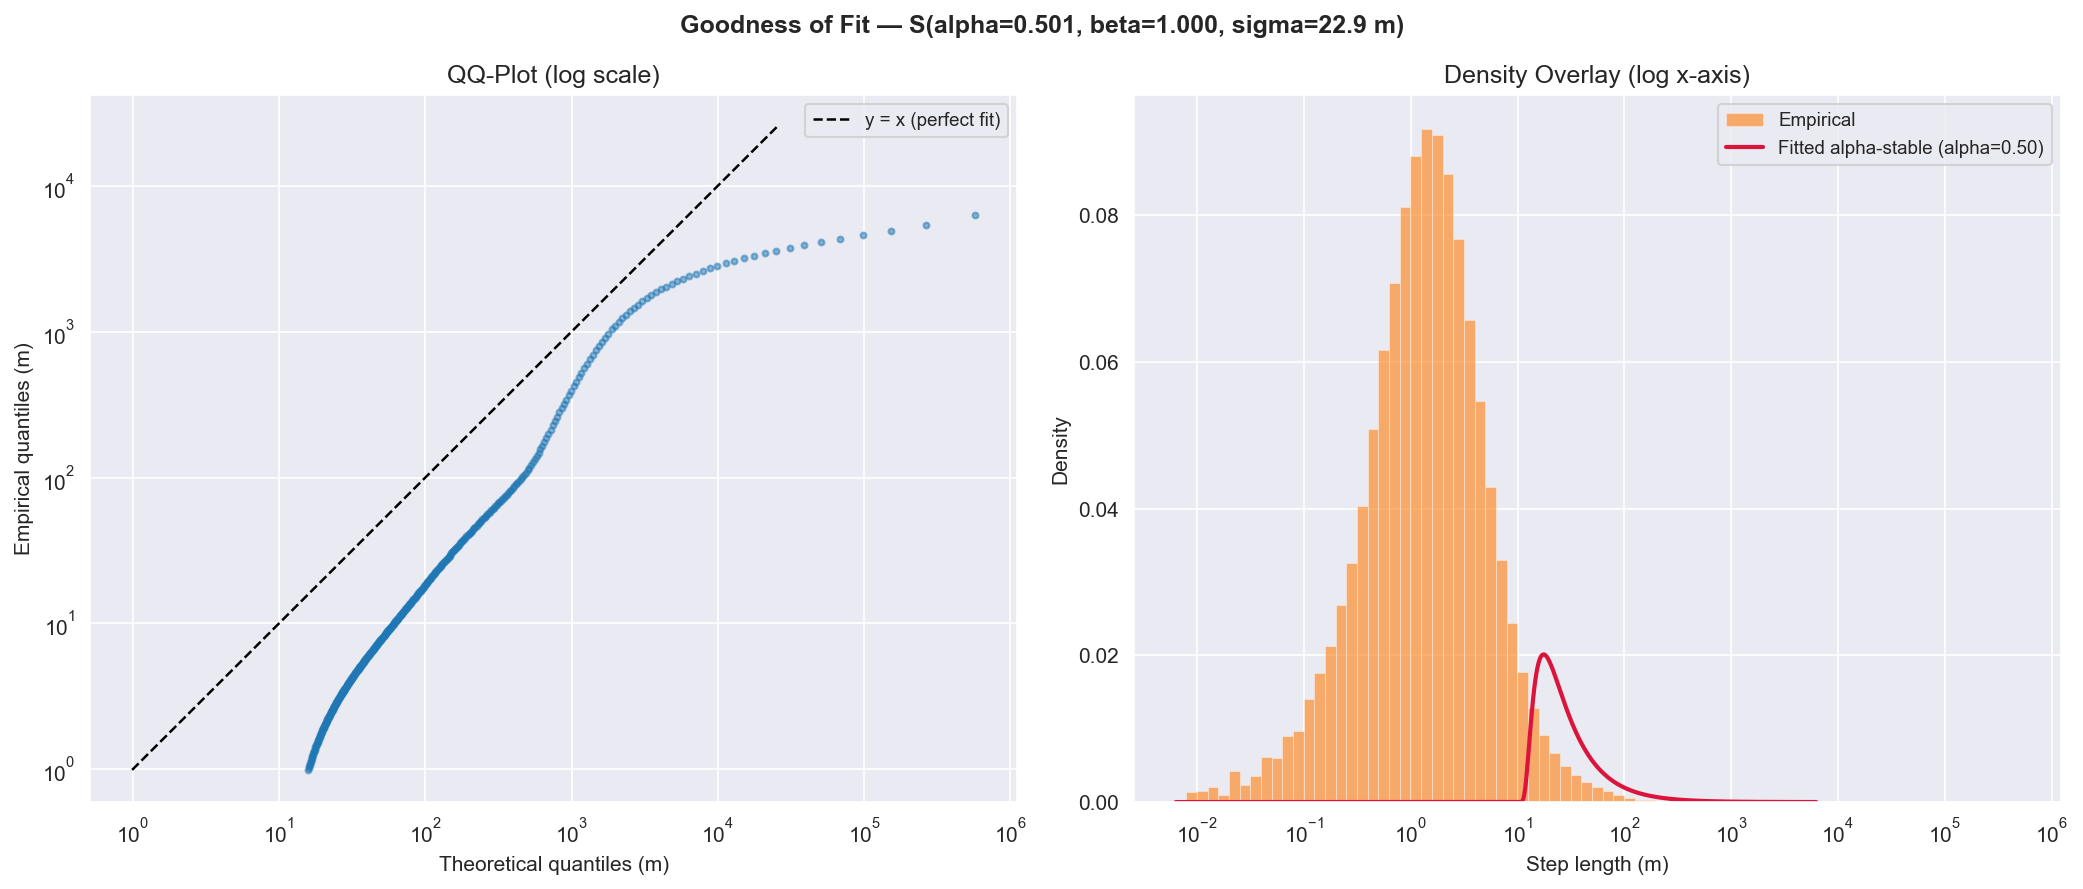

In [14]:
p = results["McCulloch"]
alpha_fit = p["alpha"]
beta_fit  = p["beta"]
sigma_fit = p["sigma"]
mu_fit    = p["mu"]

# Restrict to upper quantiles where both empirical and theoretical values are positive
probs = np.linspace(0.05, 0.995, 400)
q_th  = levy_stable.ppf(probs, alpha_fit, beta_fit, loc=mu_fit, scale=sigma_fit)
q_emp = np.quantile(step_vals, probs)
pos_mask = q_th > 0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f"Goodness of Fit — S(alpha={alpha_fit:.3f}, beta={beta_fit:.3f}, sigma={sigma_fit:.1f} m)",
    fontweight="bold",
)

# QQ plot (log scale, positive quantiles only)
ax = axes[0]
ax.scatter(q_th[pos_mask], q_emp[pos_mask], s=8, alpha=0.5, color=PALETTE[0], zorder=3)
lim_lo = min(q_th[pos_mask].min(), q_emp[pos_mask].min())
lim_hi = np.percentile(np.concatenate([q_th[pos_mask], q_emp[pos_mask]]), 99)
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", linewidth=1.2, label="y = x (perfect fit)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Theoretical quantiles (m)")
ax.set_ylabel("Empirical quantiles (m)")
ax.set_title("QQ-Plot (log scale)")
ax.legend(fontsize=9)

# Density overlay (log x-axis)
ax = axes[1]
bins = np.logspace(np.log10(step_vals.min()), np.log10(step_vals.max()), 80)
ax.hist(step_vals, bins=bins, density=True,
        color=PALETTE[1], alpha=0.6, edgecolor="white", linewidth=0.3, label="Empirical")
x_grid = np.logspace(np.log10(step_vals.min()), np.log10(np.percentile(step_vals, 99.5)), 600)
pdf_stable = levy_stable.pdf(x_grid, alpha_fit, beta_fit, loc=mu_fit, scale=sigma_fit)
ax.plot(x_grid, pdf_stable, color="crimson", linewidth=2,
        label=f"Fitted alpha-stable (alpha={alpha_fit:.2f})")
ax.set_xscale("log")
ax.set_xlabel("Step length (m)")
ax.set_ylabel("Density")
ax.set_title("Density Overlay (log x-axis)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
    

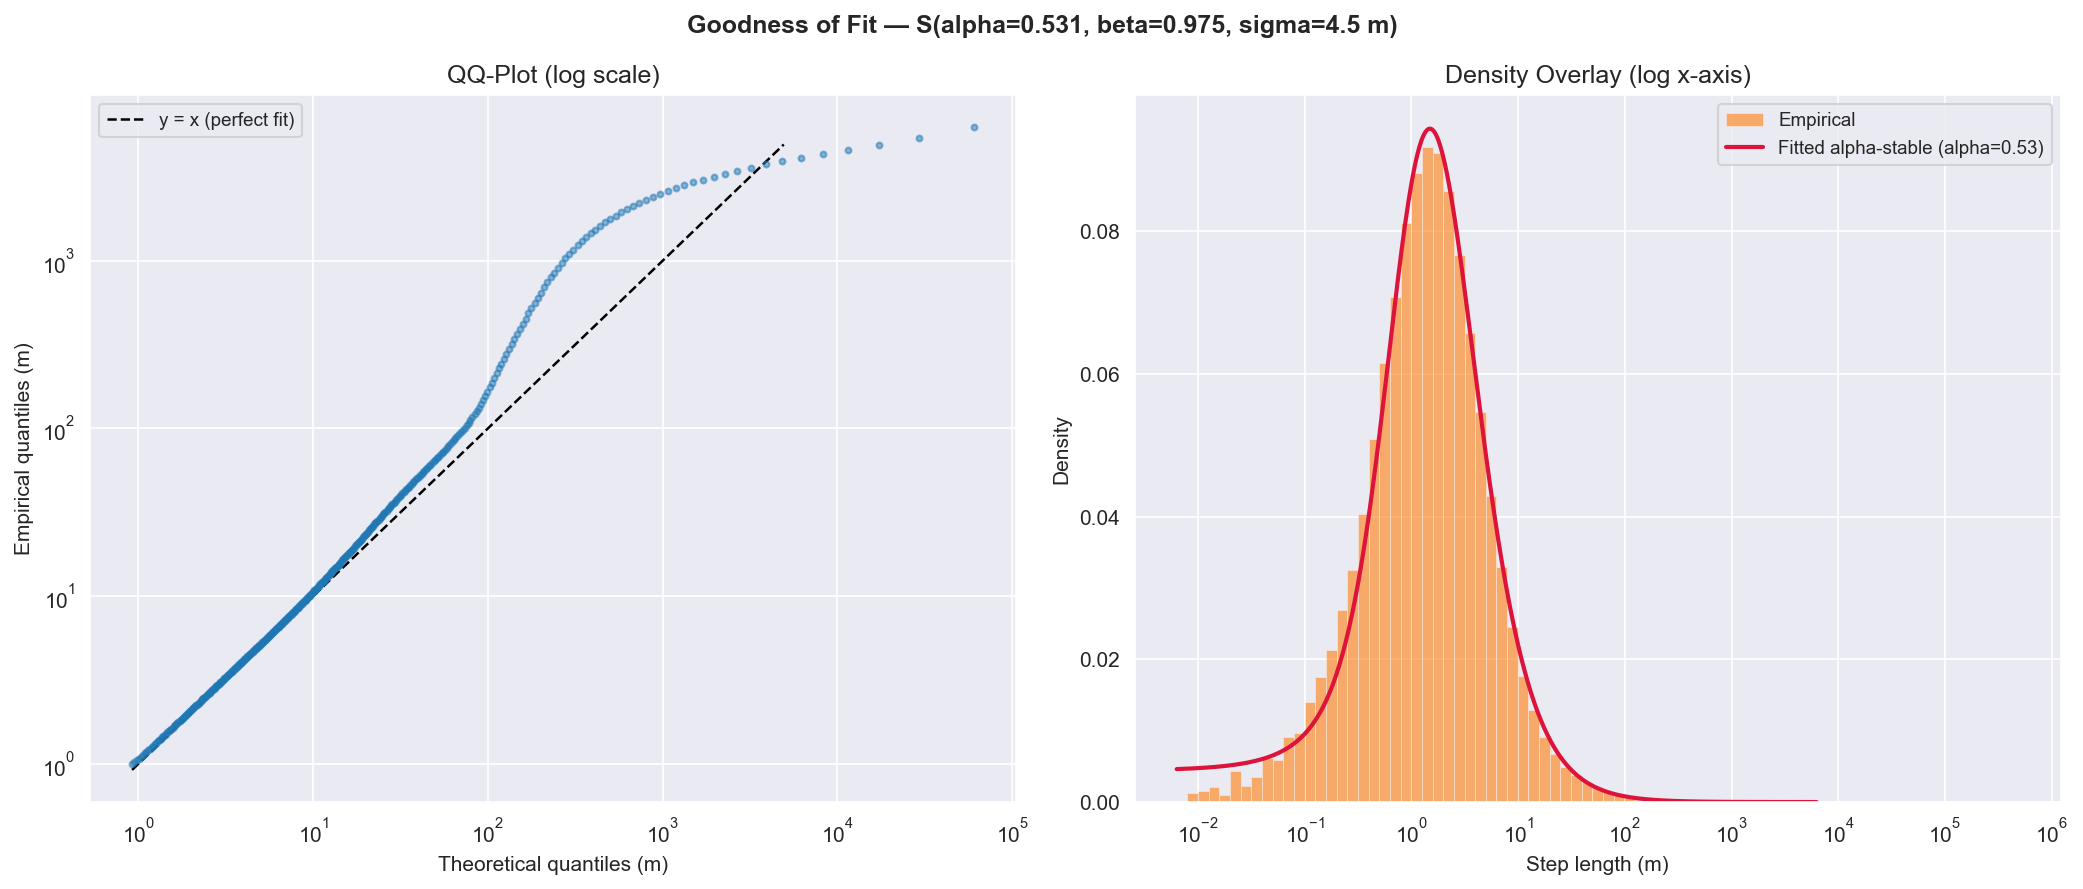

In [22]:
p = results["Koutrouvelis"]
alpha_fit = p["alpha"]
beta_fit  = p["beta"]
sigma_fit = p["sigma"]
mu_fit    = p["mu"]

# Restrict to upper quantiles where both empirical and theoretical values are positive
probs = np.linspace(0.05, 0.995, 400)
q_th  = levy_stable.ppf(probs, alpha_fit, beta_fit, loc=mu_fit, scale=sigma_fit)
q_emp = np.quantile(step_vals, probs)
pos_mask = q_th > 0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f"Goodness of Fit — S(alpha={alpha_fit:.3f}, beta={beta_fit:.3f}, sigma={sigma_fit:.1f} m)",
    fontweight="bold",
)

# QQ plot (log scale, positive quantiles only)
ax = axes[0]
ax.scatter(q_th[pos_mask], q_emp[pos_mask], s=8, alpha=0.5, color=PALETTE[0], zorder=3)
lim_lo = min(q_th[pos_mask].min(), q_emp[pos_mask].min())
lim_hi = np.percentile(np.concatenate([q_th[pos_mask], q_emp[pos_mask]]), 99)
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", linewidth=1.2, label="y = x (perfect fit)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Theoretical quantiles (m)")
ax.set_ylabel("Empirical quantiles (m)")
ax.set_title("QQ-Plot (log scale)")
ax.legend(fontsize=9)

# Density overlay (log x-axis)
ax = axes[1]
bins = np.logspace(np.log10(step_vals.min()), np.log10(step_vals.max()), 80)
ax.hist(step_vals, bins=bins, density=True,
        color=PALETTE[1], alpha=0.6, edgecolor="white", linewidth=0.3, label="Empirical")
x_grid = np.logspace(np.log10(step_vals.min()), np.log10(np.percentile(step_vals, 99.5)), 600)
pdf_stable = levy_stable.pdf(x_grid, alpha_fit, beta_fit, loc=mu_fit, scale=sigma_fit)
ax.plot(x_grid, pdf_stable, color="crimson", linewidth=2,
        label=f"Fitted alpha-stable (alpha={alpha_fit:.2f})")
ax.set_xscale("log")
ax.set_xlabel("Step length (m)")
ax.set_ylabel("Density")
ax.set_title("Density Overlay (log x-axis)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
    

In [8]:
np.random.seed(42)
n_ks  = min(len(step_vals), 2000)
s_ks  = np.random.choice(step_vals, n_ks, replace=False)

ks_stat, ks_pval = kstest(
    s_ks,
    lambda x: levy_stable.cdf(x, alpha_fit, beta_fit, loc=mu_fit, scale=sigma_fit),
)

print(f"KS test on step_m  (subsample n = {n_ks:,})")
print(f"  D statistic : {ks_stat:.4f}")
print(f"  p-value     : {ks_pval:.4e}")
if ks_pval > 0.05:
    print("  -> Cannot reject alpha-stable fit at 5% level.")
else:
    print("  -> Reject alpha-stable fit at 5% level.")

KS test on step_m  (subsample n = 2,000)
  D statistic : 0.0588
  p-value     : 1.8445e-06
  -> Reject alpha-stable fit at 5% level.


## 5. Per-Individual Analysis

**McCulloch** and **Koutrouvelis estimators** applied to each bird with ≥ 100 valid steps.


In [9]:
MIN_STEPS = 100

per_bird = {}
for bird, grp in df_whitestorks.groupby("individual_id"):
    s_b = grp["step_m"].values
    if len(s_b) < MIN_STEPS:
        continue
    row = {"n": len(s_b)}
    for est_name, est_fn in [("mcc", mcculloch_estimator), ("kou", koutrouvelis_estimator)]:
        try:
            a, b, s, m = est_fn(s_b)
            row[f"alpha_{est_name}"] = a
            row[f"beta_{est_name}"]  = b
        except Exception as e:
            print(f"  {est_name} | {bird}: failed ({e})")
    per_bird[bird] = row

per_bird_df = (
    pd.DataFrame(per_bird).T
    .dropna(subset=["alpha_mcc", "alpha_kou"])
    .sort_values("alpha_mcc")
)
print(f"Individuals fitted: {len(per_bird_df)}")
display(per_bird_df.round(3))
print(per_bird_df["beta_kou"].min(), per_bird_df["beta_kou"].max())
print(per_bird_df["beta_mcc"].min(), per_bird_df["beta_mcc"].max())

Individuals fitted: 72


,n,alpha_mcc,beta_mcc,alpha_kou,beta_kou
DER AP803,7107.0,0.500,1.0,0.743,1.000
DER AR442,1517.0,0.500,1.0,0.599,0.614
DER AP808,6780.0,0.500,1.0,0.796,0.994
ZAC 9A69901,1857.0,0.500,1.0,0.582,1.000
DER AP804,6953.0,0.500,1.0,0.816,1.000
...,...,...,...,...,...
C64W,8132.0,1.090,1.0,0.834,1.000
DER AP923,1412.0,1.108,1.0,0.546,0.828
Swag (DER AL583),1853.0,1.247,1.0,0.925,1.000
Kakau (DER AN864),37779.0,1.302,1.0,0.572,0.900


0.28537554681560245 1.0
1.0 1.0


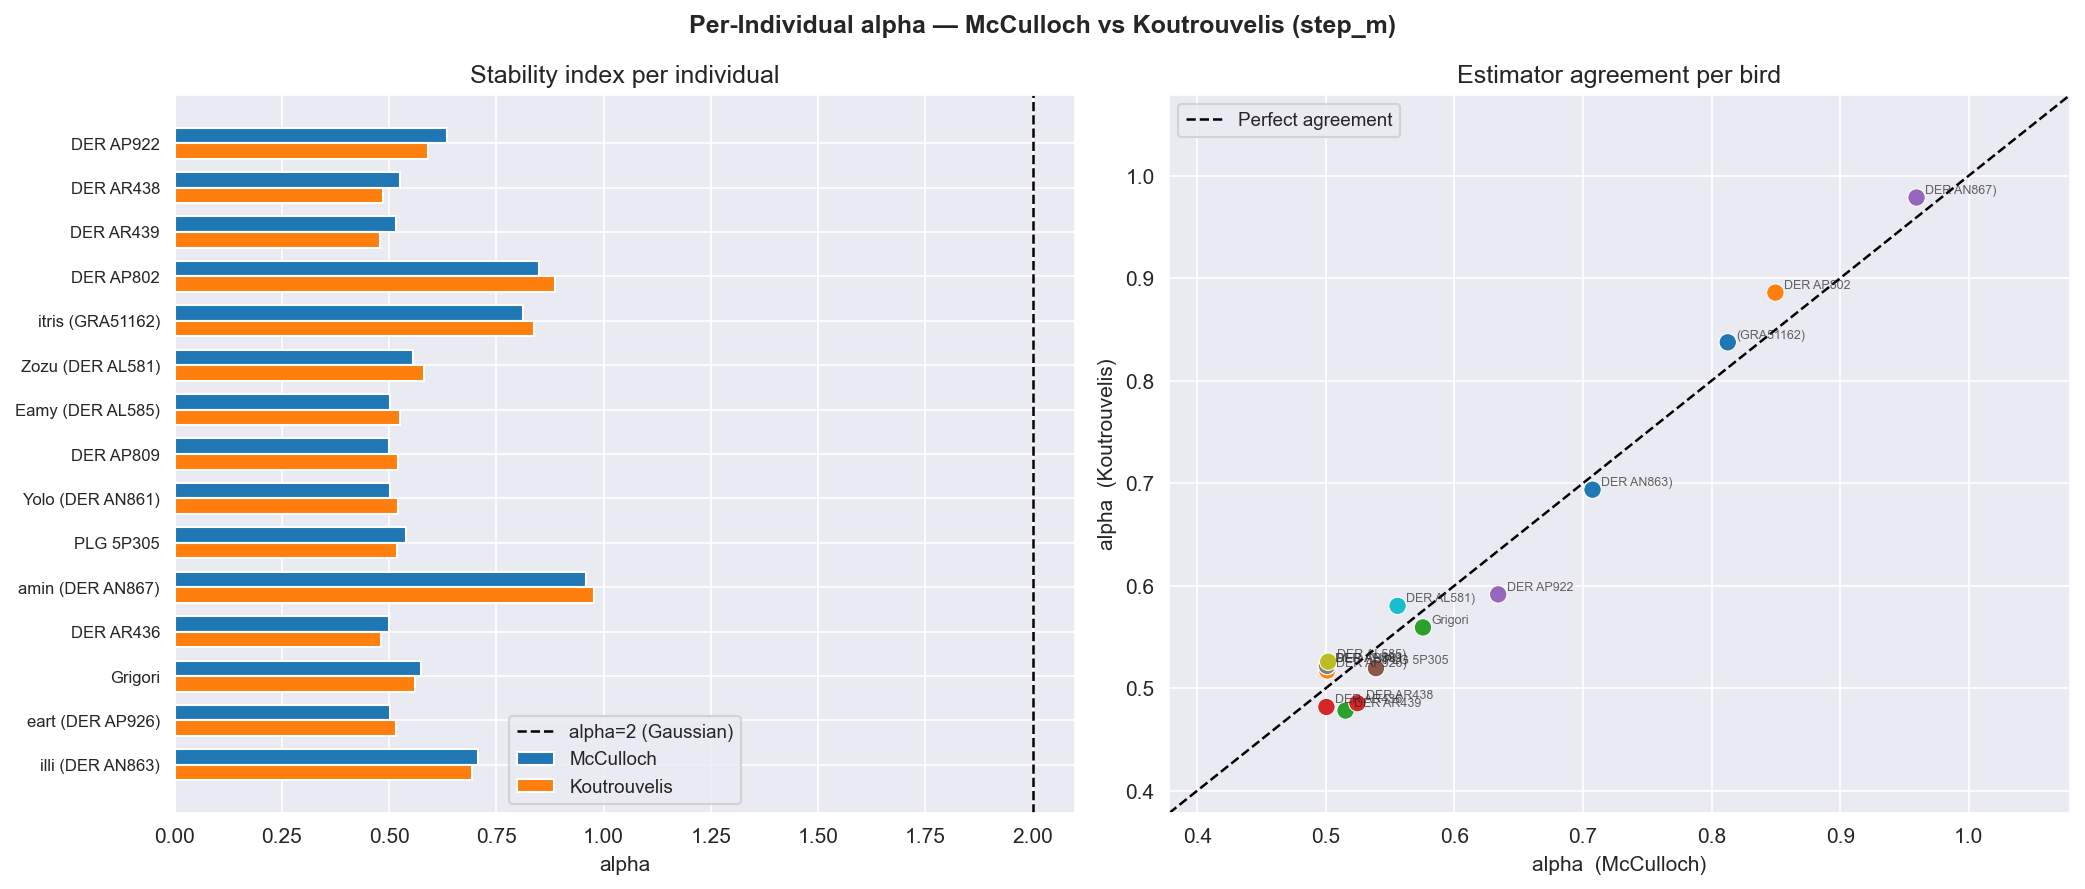

In [10]:

top15 = (
    (per_bird_df["alpha_mcc"] - per_bird_df["alpha_kou"])
    .abs()
    .sort_values()
    .head(15)
    .index.tolist()
)
top_df = per_bird_df.loc[top15]

birds   = top_df.index.tolist()
alp_mcc = top_df["alpha_mcc"].values
alp_kou = top_df["alpha_kou"].values

bird_colors = [PALETTE[i % 10] for i in range(15)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Per-Individual alpha — McCulloch vs Koutrouvelis (step_m)", fontweight="bold")

# Grouped horizontal bar chart
ax = axes[0]
y = np.arange(15)
h = 0.35
ax.barh(y + h/2, alp_mcc, height=h, color=PALETTE[0], edgecolor="white", label="McCulloch")
ax.barh(y - h/2, alp_kou, height=h, color=PALETTE[1], edgecolor="white", label="Koutrouvelis")
ax.axvline(2.0, color="black", linestyle="--", linewidth=1.2, label="alpha=2 (Gaussian)")
ax.set_yticks(y)
ax.set_yticklabels([str(b)[-16:] for b in birds], fontsize=8)
ax.set_xlabel("alpha")
ax.set_title("Stability index per individual")
ax.legend(fontsize=9)

# Scatter: agreement between estimators
ax = axes[1]
ax.scatter(alp_mcc, alp_kou, c=bird_colors, s=70, edgecolor="white", linewidth=0.5, zorder=3)
for bird, am, ak in zip(top15, alp_mcc, alp_kou):
    ax.annotate(str(bird)[-10:], (am, ak), fontsize=6, alpha=0.7,
                xytext=(4, 2), textcoords="offset points")
lo = min(alp_mcc.min(), alp_kou.min()) - 0.1
hi = max(alp_mcc.max(), alp_kou.max()) + 0.1
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.2, label="Perfect agreement")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("alpha  (McCulloch)")
ax.set_ylabel("alpha  (Koutrouvelis)")
ax.set_title("Estimator agreement per bird")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

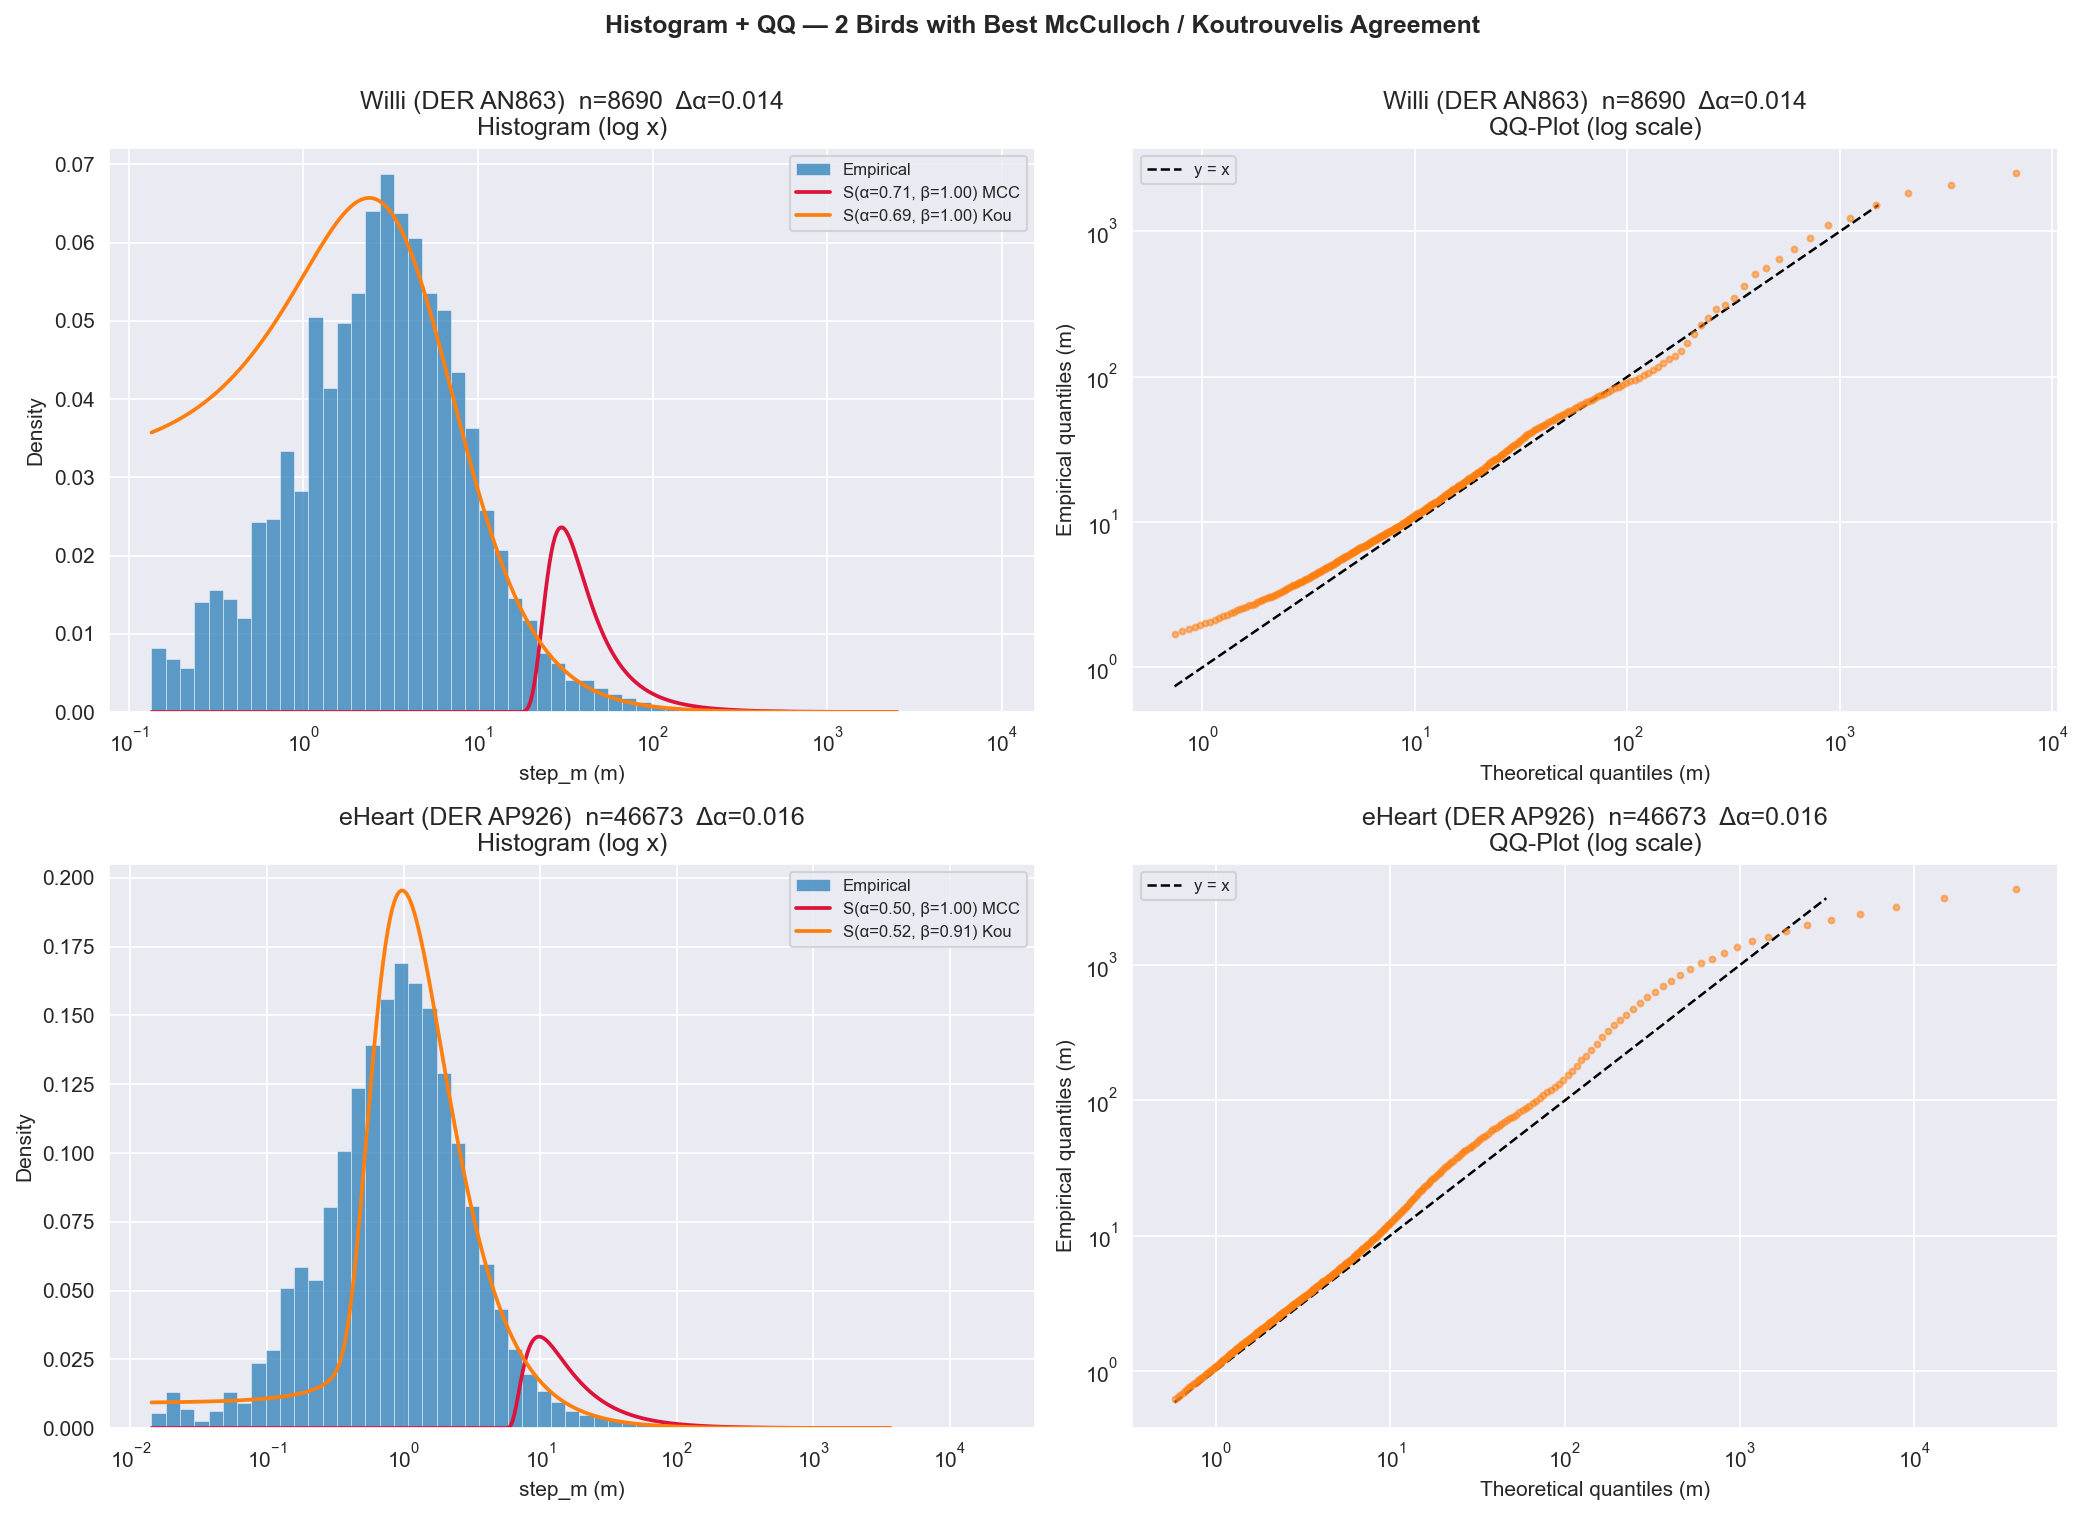

In [18]:
top2 = (
    (per_bird_df["alpha_mcc"] - per_bird_df["alpha_kou"])
    .abs()
    .sort_values()
    .head(2)
    .index.tolist()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Histogram + QQ — 2 Birds with Best McCulloch / Koutrouvelis Agreement",
    fontweight="bold", y=1.005,
)

for row, bird in enumerate(top2):
    s_b = df_whitestorks[df_whitestorks["individual_id"] == bird]["step_m"].values

    # refit McCulloch to get full (alpha, beta, sigma, mu)
    alpha_b_kou, beta_b_kou, sigma_b_kou, mu_b_kou = koutrouvelis_estimator(s_b)
    alpha_b_mcc, beta_b_mcc, sigma_b_mcc, mu_b_mcc = mcculloch_estimator(s_b)

    delta = abs(per_bird_df.loc[bird, "alpha_mcc"] - per_bird_df.loc[bird, "alpha_kou"])
    label = f"{str(bird)[-18:]}  n={len(s_b)}  Δα={delta:.3f}"

    # --- Histogram + fitted PDF ---
    ax = axes[row, 0]
    bins = np.logspace(np.log10(s_b.min()), np.log10(s_b.max()), 60)
    ax.hist(s_b, bins=bins, density=True,
            color=PALETTE[0], edgecolor="white", linewidth=0.3, alpha=0.7, label="Empirical")
    x_grid = np.logspace(np.log10(s_b.min()), np.log10(np.percentile(s_b, 99.5)), 400)

    pdf_mcc = levy_stable.pdf(x_grid, alpha_b_mcc, beta_b_mcc, loc=mu_b_mcc, scale=sigma_b_mcc)
    ax.plot(x_grid, pdf_mcc, color="crimson", linewidth=1.8,
            label=f"S(α={alpha_b_mcc:.2f}, β={beta_b_mcc:.2f}) MCC")
    
    pdf_kou = levy_stable.pdf(x_grid, alpha_b_kou, beta_b_kou, loc=mu_b_kou, scale=sigma_b_kou)
    ax.plot(x_grid, pdf_kou, color=PALETTE[1], linewidth=1.8, 
            label=f"S(α={alpha_b_kou:.2f}, β={beta_b_kou:.2f}) Kou")
    
    ax.set_xscale("log")
    ax.set_xlabel("step_m (m)")
    ax.set_ylabel("Density")
    ax.set_title(f"{label}\nHistogram (log x)")
    ax.legend(fontsize=8)

    # --- QQ plot ---
    ax = axes[row, 1]
    probs  = np.linspace(0.05, 0.995, 300)
    q_th   = levy_stable.ppf(probs, alpha_b_kou, beta_b_kou, loc=mu_b_kou, scale=sigma_b_kou)
    q_emp  = np.quantile(s_b, probs)
    mask   = q_th > 0
    ax.scatter(q_th[mask], q_emp[mask], s=8, alpha=0.5, color=PALETTE[1], zorder=3)
    lo = min(q_th[mask].min(), q_emp[mask].min())
    hi = np.percentile(np.concatenate([q_th[mask], q_emp[mask]]), 99)
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.2, label="y = x")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Theoretical quantiles (m)")
    ax.set_ylabel("Empirical quantiles (m)")
    ax.set_title(f"{label}\nQQ-Plot (log scale)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. For comparison with the $\alpha$-stable distribution, we additionally consider three commonly used models for step-length data:

- **Gamma distribution**  
  A positive-valued distribution widely used in movement ecology. It models short-to-moderate step lengths well and represents a thin-tailed alternative to Lévy-like behavior.
  Probability Density Function (PDF):$$f(x; \alpha, \beta) = \frac{\beta^\alpha x^{\alpha-1} e^{-\beta x}}{\Gamma(\alpha)} \quad \text{for } x > 0$$where $\alpha$ is the shape parameter, $\beta$ is the rate parameter, and $\Gamma(\alpha)$ is the gamma function.

- **Log-normal distribution**  
  Assumes that the logarithm of step lengths follows a normal distribution. It produces heavier tails than the Gamma distribution and is often used when occasional long movements occur.
  Probability Density Function (PDF):$$f(x; \mu, \sigma) = \frac{1}{x\sigma\sqrt{2\pi}} \exp\left( -\frac{(\ln x - \mu)^2}{2\sigma^2} \right) \quad \text{for } x > 0$$where $\mu$ and $\sigma$ are the mean and standard deviation of the variable’s natural logarithm.

- **Truncated Pareto distribution**  
  A power-law model with an exponential cutoff. It captures heavy-tailed behavior characteristic of Lévy flights while remaining biologically realistic by limiting extremely large steps.
  Probability Density Function (PDF):$$f(x; \alpha, x_{min}, x_{max}) = \frac{\alpha x_{min}^\alpha x^{-\alpha-1}}{1 - (x_{min}/x_{max})^\alpha} \quad \text{for } x_{min} \le x \le x_{max}$$where $\alpha$ is the shape parameter (tail index), and the interval $[x_{min}, x_{max}]$ defines the realistic bounds for the organism's movement.

In [12]:
DISTRIBUTIONS = ["gamma", "lognorm", "trunc_pareto"]

params_dict = {}

print(f"{'Distribution':<15} Parameters")
print("-" * 80)

for dict_name in DISTRIBUTIONS:
    try:
        params = fit_dist(step_vals, dict_name)
        params_dict[dict_name] = params

        param_str = ", ".join([f"{name}={value:.6f}" for name, value in params.items()])
        print(f"{dict_name:<15} {param_str}")

    except Exception as e:
        params_dict[dict_name] = None
        print(f"{dict_name:<15} Error: {e}")

Distribution    Parameters
--------------------------------------------------------------------------------
gamma           alpha=0.228410, loc=0.000000, scale=1709.821995
lognorm         sigma=2.260060, mu=2.812438, loc=0.000000


c:\Users\User1\studia\magisterskie\Computer_modelling\PWR_Stochastic_Process\src\estimators.py:176: RuntimeWarning: overflow encountered in power
  pdf = C * x**(-alpha - 1)
c:\Users\User1\studia\magisterskie\Computer_modelling\PWR_Stochastic_Process\src\estimators.py:176: RuntimeWarning: invalid value encountered in multiply
  pdf = C * x**(-alpha - 1)
c:\Users\User1\studia\magisterskie\Computer_modelling\PWR_Stochastic_Process\.venv\Lib\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


trunc_pareto    alpha=0.000001, xmin=0.006307, xmax=493325.071512


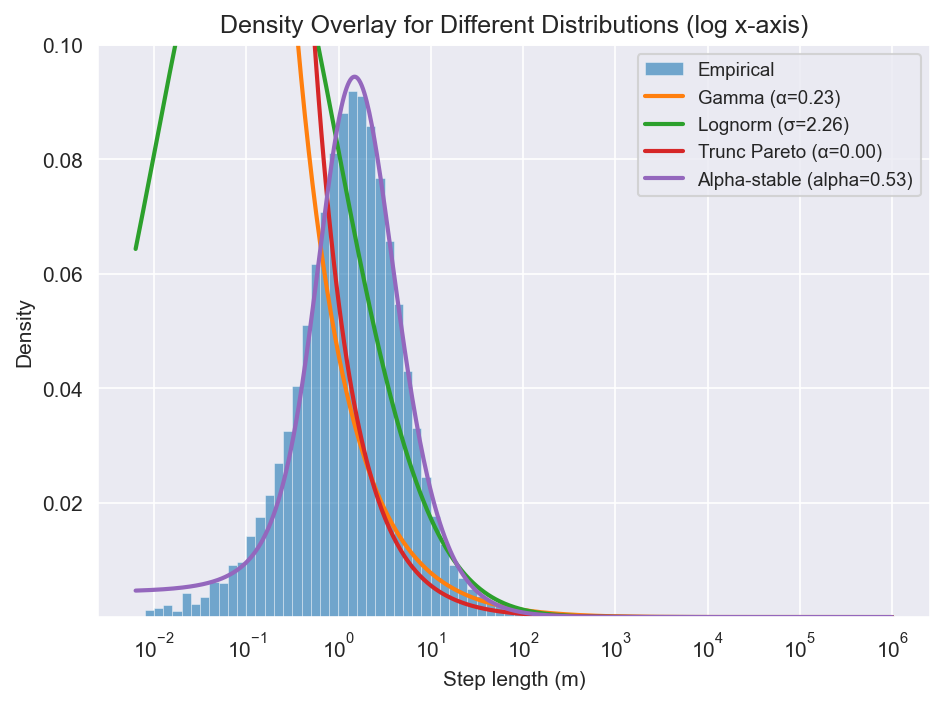

In [23]:
fig, axes = plt.subplots(1, 1)
ax = axes

bins = np.logspace(np.log10(step_vals.min()), np.log10(step_vals.max()), 80)
ax.hist(step_vals, bins=bins, density=True, alpha=0.6, edgecolor="white", linewidth=0.3, label="Empirical")

x_grid = np.logspace(np.log10(step_vals.min()), np.log10(1e6), 600)

p = params_dict["gamma"]
ax.plot(x_grid, gamma.pdf(x_grid, p["alpha"], loc=p["loc"], scale=p["scale"]), linewidth=2,
        label=f"Gamma (α={p['alpha']:.2f})")

p = params_dict["lognorm"]
ax.plot(x_grid, lognorm.pdf(x_grid, p["sigma"], loc=p["loc"], scale=np.exp(p["mu"])), linewidth=2, label=f"Lognorm (σ={p['sigma']:.2f})")

p = params_dict["trunc_pareto"]
alpha, xmin, xmax = p["alpha"], p["xmin"], p["xmax"]
C = (alpha * xmin**alpha) / (1 - (xmin / xmax)**alpha)
ax.plot(x_grid, C * x_grid**(-alpha - 1), linewidth=2, label=f"Trunc Pareto (α={alpha:.2f})")

pdf_stable = levy_stable.pdf(x_grid, alpha_fit, beta_fit, loc=mu_fit, scale=sigma_fit)
ax.plot(x_grid, pdf_stable, linewidth=2,
        label=f"Alpha-stable (alpha={alpha_fit:.2f})")

ax.set_xscale("log")
#ax.set_yscale("log")
ax.set_ylim(1e-6, 0.10)
ax.set_xlabel("Step length (m)")
ax.set_ylabel("Density")
ax.set_title("Density Overlay for Different Distributions (log x-axis)")
ax.legend(fontsize=9)



plt.tight_layout()
plt.show()